Du skal her utføre diverse analyser av data som er loggført for supportavdelingen ved
telefonselskapet MORSE. Enhver kundehenvendelse til MORSE blir loggført i en xlsx-fil og du
skal i dette prosjektet jobbe med dataloggen for uke 24. Filen ‘support_uke_24.xlsx’ finner
du sammen med prosjektoppgaven i Canvas under menyen Oppgaver -> Prosjektoppgaven,
og filen er organisert på følgende måte:


Del a) Skriv et program som leser inn filen ‘support_uke_24.xlsx’ og lagrer data fra kolonne 1
i en array med variablenavn ‘u_dag’, dataen i kolonne 2 lagres i arrayen ‘kl_slett’, data i
kolonne 3 lagres i arrayen ‘varighet’ og dataen i kolonne 4 lagres i arrayen ‘score’. Merk:
filen ‘support_uke_24.xlsx’ må ligge i samme mappe som Python-programmet ditt.

In [2]:
import numpy as np # importerer alltid denne
import pandas as pd #bruker panda for å jobbe med excel


support = pd.read_excel("support_uke_24.xlsx") #leser inn lagret fil ‘support_uke_24.xlsx’ 

u_dag = support["Ukedag"].to_numpy() # Henter ut kolonne fra support_uke_24 og lager array

kl_slett = support ["Klokkeslett"].to_numpy()

varighet = support ["Varighet"].to_numpy()

score = support ["Tilfredshet"].to_numpy()

#print(score)





Del b) Skriv et program som finner antall henvendelser for hver de 5 ukedagene. Resultatet
visualiseres ved bruk av et søylediagram (stolpediagram).

Forskjellige dager er ['Fredag' 'Mandag' 'Onsdag' 'Tirsdag' 'Torsdag']
Antall anrop på forskjellige dager er [42 51 45 44 35]


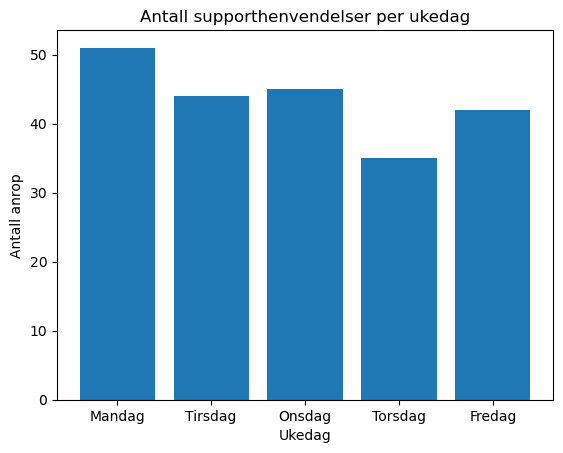

In [6]:
#strategi med å telle antall mandager, tirsdager etc

import matplotlib.pyplot as plt #supplerer med matplotlib for illustrasjon

forskjellige_dager, antall_anrop = np.unique(u_dag, return_counts=True) # lager 2 arrayer for hhv dager og antall/dag

print ("Forskjellige dager er", forskjellige_dager)   #sortererer irriterende nok alfabetisk, anaconda assistant foreslår liste
print ( "Antall anrop på forskjellige dager er", antall_anrop)

#finner funksjon for å rette opp ukedagene fra det alfabetiske - antagelig er ikke dette beste metode...

rekkefolge = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag", "Lørdag", "Søndag"]

n = np.argsort([rekkefolge.index(dag) for dag in forskjellige_dager])

forskjellige_dager = forskjellige_dager[n]
antall_anrop = antall_anrop[n]


plt.bar(forskjellige_dager, antall_anrop)

# Tittel og aksetekst
plt.title("Antall supporthenvendelser per ukedag")
plt.xlabel("Ukedag")
plt.ylabel("Antall anrop")

# Viser diagrammet
plt.show()

Del c) Skriv et program som finner minste og lengste samtaletid som er loggført for uke 24.
Svaret skrives til skjerm med informativ tekst.

In [10]:
lengste_samtale = max(varighet) # egen funksjon for å finne største i arrayen vargihet

korteste_samtale = min(varighet) # svarende til over, men korteste



print("lengeste samtale varte", lengste_samtale, "minutter og sekunder, og det korteste", 
      korteste_samtale, "sekunder")

lengeste samtale varte 00:11:28 minutter og sekunder, og det korteste 00:00:59 sekunder


Del d) KREVENDE: Skriv et program som regner ut gjennomsnittlig samtaletid basert på alle
henvendelser i uke 24

In [13]:
# strategi med å finne funksjon som konverterer arrayen til sekunder
# jeg får ikke til dette gjennom numpy på arrayen, bruker anaconda assist med anbefaling om
# panda som er kompatibelt med å konvertere direkte til numpys timedelta64 som lager array i sekunder
# panda lastet inn ifbm opplasting av excel fil 

varighet_sekunder = pd.to_timedelta(varighet).total_seconds() #konverterer til sekunder for input i varighet

#print(varighet_sekunder) #ser meningsfullt ut

gjennomsnitt_sekunder = np.round(np.mean(varighet_sekunder),2) #regner ut snittet i sekunder med 2 desimaler

#print(gjennomsnitt_sekunder) # ser meningsfullt ut

minutter, gjenværende_sekunder = divmod(gjennomsnitt_sekunder, 60) #modulusregning/rest gir ut to tall for hhv minutter og rest/ sekunder
print("Gjennomsnitlig samtale varer", int(minutter), "minutter og", int(np.round(gjenværende_sekunder,0)), "sekunder") #konverterer flyttall til heltall med int for å slippe komma i svar



Gjennomsnitlig samtale varer 6 minutter og 40 sekunder


Del e) Supportvaktene i MORSE er delt inn i 2-timers bolker: kl 08-10, kl 10-12, kl 12-14 og kl
14-16. Skriv et program som finner det totale antall henvendelser supportavdelingen mottok
for hver av tidsrommene 08-10, 10-12, 12-14 og 14-16 for uke 24. Resultatet visualiseres ved
bruk av et sektordiagram (kakediagram).

Text(0.5, 1.0, 'Antall supporthenvendelser i prosent innenfor gitte tidsrom')

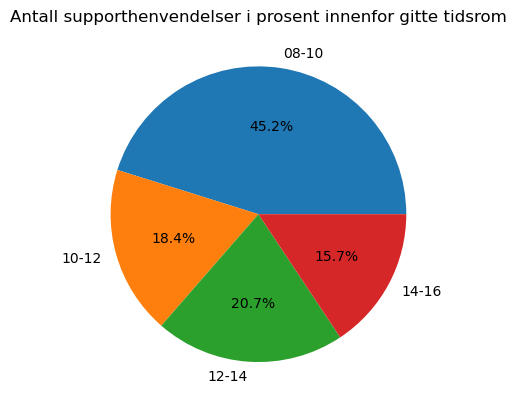

In [15]:
#strategi med if-løkke som teller gjennom arrayen kl_slett

#etablerer tidsintervallene, 0 før de fylles opp etterhvert so løkken går


kl_08_10 = 0
kl_10_12 = 0
kl_12_14 = 0
kl_14_16 = 0

for tidspunkt in kl_slett:
    time = int(tidspunkt.split(":")[0])   # funksjon som splitter på kolon i 00:00:00, 
    #og henter ut første kolonne [0], hentet fra anaconda assist

    if 8 <= time < 10: #kjører gjennom de forskjellige intervallene og adderer 1 ved treff
        kl_08_10 += 1
    elif 10 <= time < 12:
        kl_10_12 += 1
    elif 12 <= time < 14:
        kl_12_14 += 1
    elif 14 <= time < 16:
        kl_14_16 += 1

samtaler_i_intervallene = [kl_08_10, kl_10_12, kl_12_14, kl_14_16] #samles opp i array for tidsintervallene
navn_intervaller = ["08-10", "10-12", "12-14", "14-16"] #setter på merkelapper for å kunne kjøre piechart

plt.pie(samtaler_i_intervallene, labels=navn_intervaller, autopct="%1.1f%%") #siste etter komma angir prosentene
plt.title("Antall supporthenvendelser i prosent mellom gitte klokkeslett")        

Del f) Kundens tilfredshet loggføres som tall fra 1-10 hvor 1 indikerer svært misfornøyd og
10 indikerer svært fornøyd. Disse tilbakemeldingene skal så overføres til NPS-systemet (Net
Promoter Score).
NPS-systemet er konstruert på følgende måte:
Score 1-6 oppfattes som at kunden er negativ (vil trolig ikke anbefale MORSE til andre).
Score 7-8 oppfattes som et nøytralt svar.
Score 9-10 oppfattes som at kunden er positiv (vil trolig anbefale MORSE til andre).
Supportavdelingens NPS beregnes som et tall, prosentandelen positive kunder minus
prosentandelen negative kunder. Ved en formel kan dette gis slik:
NPS = % positive kunder - % negative kunder

In [17]:
# Strategi om å kjøre if løkke som fyller opp i hhv positivte og negative bolker
# det er mange nan ved print av score

positiv=0
negativ=0
nøytral=0
ikke_registrert=0

for n in score:

    if 1 <= n < 6:      #legger til i negativ bolk
        negativ += 1
    elif 7 <= n < 8:    #legger til i nøytral bolk
        nøytral += 1
    elif 9 <= n <= 10:   # legger til i positiv bolk
        positiv += 1
    else: 
        ikke_registrert +=1   #fyller på NA

antall_gyldige_svar = len(score[~np.isnan(score)]) #~inverterer slik at det er de besvarte vi hetner ut, kalkulerer antall med len=43

positive_kunder_prosent = positiv/antall_gyldige_svar*100    #prostentvis andel positive fra besvarte skjema, finner 28 positive
negative_kunder_prosent = negativ/antall_gyldige_svar*100    #prostentvis andel negative fra besvarte skjema
NPS = positive_kunder_prosent - negative_kunder_prosent

print (" NPS som gir forskjell mellom andel positive og negative kunder i prosent svarer til", np.round(NPS, 1), "%")



 NPS som gir forskjell mellom andel positive og negative kunder i prosent svarer til 44.2 %
